*Do not delete this style setting*

In [1]:
%%html
<style>
table {float:left}
</style>

# Session 3<br> A Simple Quantum Classifier

<table>
    <tr><td><strong>Aim:</strong></td>
        <td>To explore the creation and use of a simple quantum classifier in <strong>PennyLane</strong> and <strong>PyTorch</strong>.<br>
            Compare the quantum classifier with the equivalent classical classifier.<br>
            Note that "simplicity" is only in data and the model structure - not in the approach!</td></tr>
    <tr><td><strong>Author:</strong></td>
        <td>Jacob L. Cybulski (<a href="https://jacobcybulski.com/" target="_blank">website</a>),
            <em>Enquanted</em></td></tr>
    <tr><td><strong>Release:</strong></td>
        <td>April 2025</td></tr>
    <tr><td><strong>Updated:</strong></td>
        <td>October 2026</td></tr>
    <tr><td><strong>Datasets:</strong></td>
        <td>We will use the following two datasets from UCI repository (require: pip install ucimlrepo):<br>
        <ol>
            <li><a href="https://archive.ics.uci.edu/dataset/10/automobile" target="_blank">Automobiles</a>:
              This is a database of automobile specs. The aim is to determine its insurance risk (symboling). Data loading and preprocessing was included below.</li>
            <li><a href="https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks" target="_blank">Sonar</a>:
              The aim is to discriminate between sonar signals bounced off a mine (metal cylinder) or a rock (roughly cylindrical).</li>
        </ol></td></tr>
    <tr><td><strong>Tasks:</strong></td>
        <td>40 minutes (unfinished tasks go to self-directed "challenges")</td></tr>
    <tr>
        <td></td>
        <td>Perform the following tasks<br>(record your observations at end of this notebook):<br>
        <ol>
            <li>Initially use the <strong><em>Automobiles</em></strong> dataset 1 (as provided).<br>
                Follow the instructor demonstration to step through the code.<br>
                - we will first look at a classical PyTorch model<br>
                - and then look at the quantum PyTorch+PennyLane model.</li>
            <li>Explore your dataset and think of its impact on the process and results:<br>
                - hint: consider data ordering and what needs to be done about it</li>
            <li>Can you improve the model performance by changing the approach<br>to dimensionality reduction:<br>
                - feature selection based on intuition (default) ?<br>
                - feature selection based on f_classif, mutual_info_classif, chi2 ?<br>
                - dimensionality reduction based on PCA ?<br>
                Which of these approaches had the greatest impact on performance?</li>
            <li>Improve the model by varying its architectural and training aspects.<br>
                - changes may apply to data, model and its training<br>
                - what methods have you applied and with what result ?</li>
            <li>Change your PennyLane and Torch model to allow application of<br>
                - <b>sigmoid</b> final activation function, and<br>
                - <b>BCELoss</b> cost function.<br>
                Note 1: You may need to change the quantum measurement to probability.<br>
                Note 2: You may need to add an extra layer mapping qlayer output to BCELoss.</li>
            <li>Create some data on the fantasy automobiles and use the developed model for<br>
                their classification. Does it match your expectation?</li>
            <li>Critically assess the model, its development and training!<br>
                - What principles of quantum model development were broken in the process?</li>
            <li>Compare the classical vs quantum classification models and their performance.</li>
            <li>Reflect on this session.</li>
        </ol></td>
    </tr>
    <tr>
        <td><strong>Challenge<br>Tasks:</strong></td>
        <td>Perform one or more of the following tasks in your own time:<br/>
        <ol style="list-style-type: upper-alpha;">
            <li>Complete the unfinished tasks.</li>
            <li>Change the quantum model by incorporating a full-reuploading ansatz.</li>
            <li>Cleanup and add nominal features to this analysis.</li>
            <li>Add an ROC curve analysis for the best model result (research).</li>
            <li>Include the quantum model definition as part of the <strong><em>Quantum_Auto</em></strong> class.</li>
            <li>Change (back) the label variable from binary to multiclass (hard), <br>
                to implement and test a multinomial classification model (research).</li>
            <li>Create a confusion matrix, with sensitivity and specificity for each class (research).</li>
            <li>Address the critical flaws in the model and its development process.<br>
                - Did you have to retrace the entire experimental process?<br>
                - What is the quantum performance afterwards?<br>
                - What does it mean?</li>
            <li>Apply your completed model to the <strong><em>Sonar</em></strong> data set 2</li>
        </ol></td>
    </tr>
    <tr><td><strong>References:</strong></td>
        <td><ul>
            <li><a href = "https://www.youtube.com/watch?v=OIenNRt2bjg" target="_blank">
                AssemblyAI, “PyTorch Crash Course - Getting Started with Deep Learning”,<br>YouTube Video, Jul 2022.</a></li>
            <li><a href = "https://pennylane.ai/qml/demos/tutorial_qnn_module_torch" target="_blank">Thomas Bromley, "Turning quantum nodes into Torch Layers",<br>
                PennyLane Demo, October 7, 2024.</a></li>
            <li><a href = "https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html" target="_blank">PennyLane, "qml.qnn.TorchLayer",<br>
                PennyLane Documentation, Code API, 2025.</a></li>
            <li><a href = "https://pennylane.ai/qml/demos/tutorial_local_cost_functions" target="_blank">Thomas Storwick, "Alleviating barren plateaus with local cost functions",<br>
                PennyLane Tutorial, November 6, 2024.</a></li>
        </ul></td>
    </tr>
    <tr><td><strong>License:</strong></td>
        <td>This project is licensed under the
            <a href="https://www.gnu.org/licenses/gpl-3.0.en.html" target="_blank">GNU General Public License v3</a></td></tr>
    <tr><td><strong>Changes:</strong></td>
        <td>All significant changes to this code must be recorded in this notebook</td></tr>
</table>

## Libraries

In [2]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/envs/pl-qml-2026/lib/python311.zip',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/site-packages',
 '.',
 '..']

In [3]:
### General libraries

import os
import pylab
import math
import time
import copy
import pandas as pd
from IPython.display import clear_output

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("warning")

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [4]:
### Import utilities
from utilities import multi_plot_hist, multi_plot_series, draw_circuit

In [5]:
### ML packages

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.model_selection import train_test_split

In [6]:
### Import PennyLane and Torch
import pennylane as qml
from pennylane import numpy as np
from pennylane import NesterovMomentumOptimizer
from torch import nn, optim, sigmoid, softmax
from torch.autograd import Variable
import torch

---

## <font color="blue">Data preparation</font>

Selected dataset: <a href="https://archive.ics.uci.edu/dataset/10/automobile" target="_blank">Automobiles</a>.

In [7]:
### Dataset settings
#   Decide how many data features to be modelled (will be transformed)
n_features = 5
data_seed = 2025

### Load and understand data
*The original source of data included for reference.*

In [8]:
# from ucimlrepo import fetch_ucirepo

# auto = fetch_ucirepo(id=10)
# X_vars = auto.data.features 
# y_class = auto.data.targets 
# print(auto.metadata['additional_info']['summary'],'\n') 

In [9]:
import pandas as pd
pd.set_option('display.max_columns', None)

### Fetch data from the local repository
filepath = '../data/Automobile.csv'
headers = ['symboling','normalized-losses','make','fuel-type','aspiration', 'num-of-doors','body-style',
           'drive-wheels','engine-location','wheel-base', 'length','width','height','curb-weight','engine-type',
           'num-of-cylinders', 'engine-size','fuel-system','bore','stroke','compression-ratio','horsepower',
           'peak-rpm','city-mpg','highway-mpg','price']

automobile = pd.read_csv(filepath, sep='#', decimal='.', header=None, names=headers)

### Split data frame into X and y vectors
y_class = automobile[['symboling']]
X_vars = automobile.drop(columns=['symboling'])

In [10]:
### Convert two nominal columns to numerics
print(f"Column {'num-of-doors'} unique values: {X_vars['num-of-doors'].unique()}")
print(f"Column {'num-of-cylinders'} unique values: {X_vars['num-of-cylinders'].unique()}")

### Mapping columns to numeric values
num_doors_mapping = {'one':1, 'four':4, 'two':2, 'four ':4, 'fourR':4, 'Four':4}
num_cylinders_mapping = {'four':4, 'six':6, 'five':5, 'three':3, 'twelve':12, 'two':2, 'eight':8, 'Four':4, 'five ':5, ' four':4}

X_vars['num-of-doors'] = X_vars['num-of-doors'].map(num_doors_mapping)
X_vars['num-of-cylinders'] = X_vars['num-of-cylinders'].map(num_cylinders_mapping)

Column num-of-doors unique values: <StringArray>
['two', 'four', nan, 'Four', 'four ', 'fourR']
Length: 6, dtype: str
Column num-of-cylinders unique values: <StringArray>
[  'four',    'six',   'five',  'three', 'twelve',    'two',  'eight',
   'Four',  'five ',  ' four']
Length: 10, dtype: str


### Preprocess data

In [11]:
### Shuffle X and y together
np.random.seed(data_seed)
idx = np.random.permutation(X_vars.index)
X_vars = X_vars.reindex(idx)
X_vars.index = list(range(X_vars.shape[0]))
y_class = y_class.reindex(idx)
y_class.index = list(range(y_class.shape[0]))

### Select numerical columns only!
#   Note: we could have one-hot encoded categorical
X_sel = X_vars.select_dtypes(include=np.number)

### Eliminate missing values with column mean
auto_xmean = X_sel.mean()
X_sel = X_sel.fillna(auto_xmean)

# Standardise all variables
auto_scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled = auto_scaler.fit_transform(X_sel) 
X_std = pd.DataFrame(scaled, columns=X_sel.columns)

X_std.columns

Index(['normalized-losses', 'num-of-doors', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'num-of-cylinders', 'engine-size', 'bore',
       'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='str')

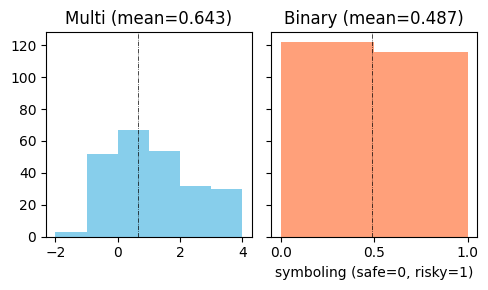

In [12]:
### Transform the label from multinomial to binomial

# Current label mean
auto_ymean = y_class["symboling"].mean()

# Create a binary label
pd.set_option('display.max_rows', 10)
y_std = pd.DataFrame(y_class)
y_std['symboling'] = np.where(y_std['symboling'] > auto_ymean, 1, 0)
y_binmean = y_std["symboling"].mean()

# Plot both distributions
plt.rcParams["figure.figsize"] = [5, 3]
fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

axs[0].hist(y_class["symboling"], bins=6, color='skyblue')
axs[0].set_title(f'Multi (mean={round(auto_ymean, 3)})')
axs[0].axvline(auto_ymean, color='k', linestyle='-.', linewidth=0.5)
axs[1].hist(y_std['symboling'], bins=2, color='lightsalmon')
axs[1].set_title(f'Binary (mean={np.round(y_binmean, 3)})')
axs[1].axvline(y_binmean, color='k', linestyle='-.', linewidth=0.5)
axs[1].set_xlabel(f'{y_std.columns[0]} (safe=0, risky=1)')

plt.show()

### Reduce data dimensionality
**Feature selection** based on PCA

In [13]:
from sklearn.decomposition import PCA

n_components = n_features
auto_pca = PCA(n_components=n_components)
X_pca = auto_pca.fit_transform(X_std)
X_pca = pd.DataFrame(X_pca, columns=[f'PC{n:02d}' for n in range(X_pca.shape[1])])
pca_var = auto_pca.explained_variance_ratio_
print(f'Explained var = {np.sum(pca_var):02.3f}')
X_pca.columns

Explained var = 0.874


Index(['PC00', 'PC01', 'PC02', 'PC03', 'PC04'], dtype='str')

**Variable selection** X, y data for moedling

In [14]:
X = X_pca.copy()
y = y_std.copy()

***

## <font color="blue">Model development</font>

### Model and training configuration

In [15]:
### Data params
n_data = X.shape[0]
x_angle_margin = 0.0               # Could be: 0.1
x_angle_min = 0+x_angle_margin     # We leave it as is
x_angle_max = 1-x_angle_margin     # Could be: np.pi-x_angle_margin

### Architectural params
n_wires = n_features  # The model ansatz may have less data than wires
n_layers = 5
wires = list(range(n_wires))

### Training params
epochs = 300     # 20 for LBFGS # 50 # 80 # 100 # 300
log_interv = 1   # History to be saved only once every interv or epochs
acc_prec = 0.5   # Precision of accuracy calculation
shots = None     # None means using theoretical frequency distribution 
seed = 2025

### Other (CASE_NAME) invariant params
diff_method = 'backprop' # best, adjoint, 
interface = 'torch'      # None, 'torch','autograd'
level ='gradient'        # 'device', 'user'
shots = None             # We use a state vector simulator

In [16]:
(n_data, n_wires, n_layers, epochs, shots)

(238, 5, 5, 300, None)

### Define device to compute on

In [17]:
### Find what devices are available

# Quantum simulator
sim = 'default.qubit' # default.qubit lightning.qubit lightning.gpu

# Enable GPU device if available
if torch.cuda.is_available():   # for Linux / Windows with GPU
    torch_device = 'cuda'
elif torch.mps.is_available():  # for Mac with GPU
    torch_device = 'mps'
else:
    torch_device = 'cpu'        # for everybody else
    
print(f'\nThe available devices:\t{sim} and {torch_device}')

# If you want to force CPU if working with GPU is slow (our unoptimised code)
torch_device = "cpu"

print(f'Devices to be used:\t{sim} and {torch_device}\n')


The available devices:	default.qubit and cpu
Devices to be used:	default.qubit and cpu



### Prepare data for the quantum classifier

In [18]:
### Standardise X values to Rxyz angles
angle_scaler = MinMaxScaler(feature_range=(x_angle_min, x_angle_max)) 
scaled = angle_scaler.fit_transform(X) 
X_ang = pd.DataFrame(scaled, columns=X.columns)

In [19]:
### Create data partitions, data has been shuffled before
X_train, X_test, y_train, y_test = train_test_split(X_ang.iloc[:,0:n_data], y.iloc[:,0:n_data], 
    test_size=0.33, shuffle=False, random_state=seed)
print(f'Shapes: X_train={X_train.shape}, X_test={X_test.shape}, ' +\
      f'y_train={y_train.shape}, y_test={y_test.shape}')

Shapes: X_train=(159, 5), X_test=(79, 5), y_train=(159, 1), y_test=(79, 1)


In [20]:
### Change the data format to tensors
X_train_tens = torch.tensor(np.array(X_train), dtype=torch.double)
y_train_tens = torch.tensor(np.array(y_train), dtype=torch.double)
X_test_tens  = torch.tensor(np.array(X_test), dtype=torch.double)
y_test_tens  = torch.tensor(np.array(y_test), dtype=torch.double)

### Utilities

In [21]:
### Performance measures

### A simple differentiable MSE cost function
def square_mse(labels, predictions):
    sq_diffs = torch.tensor([(l - p)**2 for l, p in zip(labels, predictions)])
    return sq_diffs.mean().item()

### A simple differentiable accuracy
def accuracy(labels, predictions, prec=1e-5):
    acc = sum(abs(l - p) < prec for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc.item()

### Counts the number of pytorch model parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### PennyLane model

In [22]:
### Define a simple quantum model
def qmodel(n_wires):
    wires = list(range(n_wires))
    def _qmodel(inputs, weights):
        nonlocal wires, n_wires #, meas_wires
        qml.AngleEmbedding(inputs, wires=wires)        
        qml.StronglyEntanglingLayers(weights, wires=wires)
        # return [qml.expval(qml.PauliZ(0))]
        return [qml.probs(0)] # Range [0..1] - as needed by BCELoss
    return _qmodel

In [23]:
### Check the model shape
def qshape(n_wires, n_layers=1):
    shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
    return shape

In [24]:
### Test
tdev = qml.device(sim, wires=n_wires, shots=None)
tshape = qshape(n_wires, n_layers)
tweights = torch.rand(tshape, requires_grad=True)
tmodel = qmodel(n_wires)
tcirc = qml.QNode(tmodel, tdev, interface='torch', diff_method='backprop')
print('\nSample result:', tcirc(X_train_tens[0], tweights),'\n')


Sample result: [tensor([0.4517, 0.5483], dtype=torch.float64, grad_fn=<ViewBackward0>)] 



### PyTorch model with PennyLane layer

To use PennyLane Torch layers refer to the 
<a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html" target="_blank">TorchLayer PennyLane API</a>
as well as <a href = "https://pennylane.ai/qml/demos/tutorial_qnn_module_torch" target="_blank">Thomas Bromley tute on Torch layers</a>.

In [25]:
### Create a PyTorch model with a PennyLane circuit within

class Quantum_Auto(nn.Module):

    """ 
    Implementation of the hybrid quantum-classical logistic regression
    Parameters:
    - sim: name of a PennyLane device
    - n_wires: number of wires for the quantum model (= qubits/features)
    - n_layers: number of trainable entangling layers
    - shots: number of shots per quantum execution
      if None, then theoretical outcome if calculated
    Result:
    - PyTorch model
    """
    
    def __init__(self, sim, n_wires, n_layers=1, shots=None):
        super(Quantum_Auto, self).__init__()

        self.sim = sim
        self.n_wires = n_wires
        self.n_layers = n_layers
        self.shots = shots

        # Wrap a torch layer around the PennyLane model
        quant_layer = self.qlayer()
        reduce_layer = torch.nn.Linear(2, 1)
        layers = [quant_layer, reduce_layer]
        # layers = [quant_layer]
        self.model_pt = nn.Sequential(*layers)  

    ### Define a quantum layer
    def qlayer(self):
        
        # Specify a device
        dev = qml.device(self.sim, wires=self.n_wires, shots=self.shots)

        # Define the quantum model and its circuit (or node, save it for later)
        model_pl = qmodel(self.n_wires)
        self.model_qc = qml.QNode(model_pl, dev, interface=interface, diff_method=diff_method)

        # Define the shape of the model weight parameters
        # Note that the name "weights" must match the param name defined in function 
        # "model_pl" which in our case is _qmodel(inputs, weights)
        weights_shapes = {"weights": qshape(self.n_wires, n_layers=self.n_layers)}

        # Turn the circuit into a Torch-compatible quantum layer
        quant_layer = qml.qnn.TorchLayer(self.model_qc, weight_shapes=weights_shapes)
        return quant_layer

    ### Return the quantum model circuit
    def qmodel_qc(self):
        return self.model_qc
 
    ### Apply the model to data (forward step)
    def forward(self, x):
        # y = self.model_pt(x)
        y = sigmoid(self.model_pt(x))     # maps preds to probs
        return y

### Test the PennyLane/PyTorch hybrid model before use

In [26]:
### Create a test model and draw the test model circuit
test = Quantum_Auto(sim, n_wires, n_layers=n_layers, shots=shots).double().to(torch_device)
shape = qshape(n_wires, n_layers)
n_weights = np.prod(shape)

print(f'\nAll weights: {count_params(test)}, Q weights: {n_weights}, Epochs: {epochs}')
print(f'\nTest results: {test(X_train_tens[0:5])}\n')

### Show the structure of the torch model
test.eval()


All weights: 78, Q weights: 75, Epochs: 300

Test results: tensor([[0.5865],
        [0.5849],
        [0.5829],
        [0.5842],
        [0.5848]], dtype=torch.float64, grad_fn=<SigmoidBackward0>)



Quantum_Auto(
  (model_pt): Sequential(
    (0): <Quantum Torch Layer: func=_qmodel>
    (1): Linear(in_features=2, out_features=1, bias=True)
  )
)

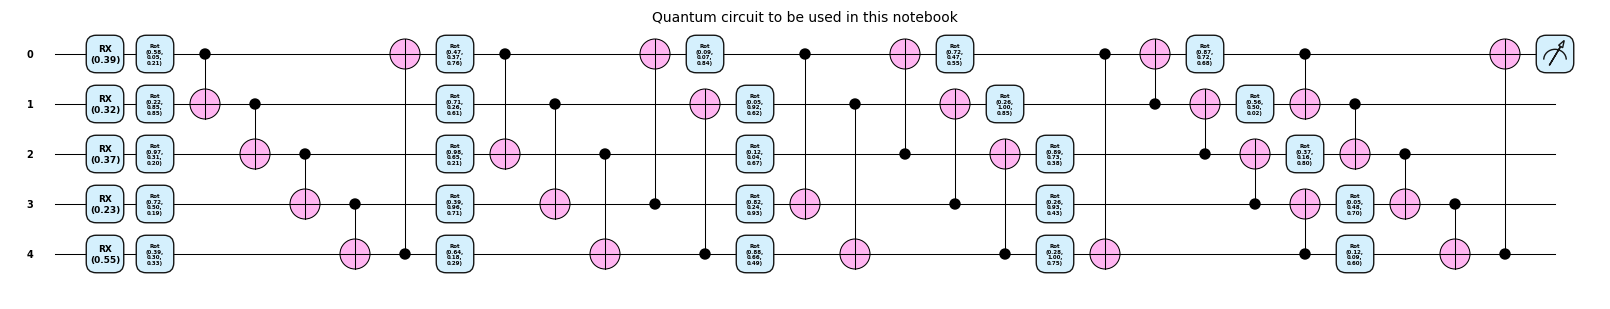

In [27]:
### Draw the test model circuit
weights = torch.rand(shape, requires_grad=True)
draw_circuit(test.qmodel_qc(), scale=0.5, title='Quantum circuit to be used in this notebook', level='device') \
    (X_train_tens[0], weights) # level='device'/'gradient'

### Creation and training of the PennyLane/PyTorch model

In [28]:
## Optional for simple gradient optimisers, such as Adam
## Required by optimisers with internal steps, such as LBFGS
## Works for both types of optimisers
def make_closure(X, Y, model, optimizer, lossfun):
    def _closure():
        nonlocal X, Y, model, optimizer, lossfun
        if torch.is_grad_enabled():
            optimizer.zero_grad()
        output = model(X)
        loss = lossfun(output, Y)
        if loss.requires_grad:
            loss.backward()
        return loss
    return _closure

In [29]:
### Trains a PyTorch model (of any kind)
def train_model(model, X, y, cost_fun, optimizer, epochs, closure=None, 
                log_interv=100, prompt_fract=0.1, start_time=0):
    
    history = []
    opt_params = {}
    hist_params = []
    min_epoch = 0
    min_cost = np.inf
    if start_time == 0: start_time = time.time()
    
    model.train()
    for epoch in range(epochs):
        
        optimizer.zero_grad()
        output = model(X)
        cost = cost_fun(output, y)
        cost.backward()
        if closure is None:
            optimizer.step()
        else:
            optimizer.step(closure)

        curr_cost = cost.item()
        if curr_cost < min_cost: 
            min_cost = curr_cost
            min_epoch = epoch
            opt_params = copy.deepcopy(model.state_dict())

        if epoch % log_interv == 0:
            history.append(curr_cost)
            hist_params.append(copy.deepcopy(model.state_dict()))

        elapsed = time.time() - start_time
        if (prompt_fract == 0) or (epoch % int(prompt_fract*epochs) == 0):
            print(f'{epoch: 5d} '+ \
                  f'({elapsed:06.0f} sec): '+ \
                  f'Cost {curr_cost:6.4g}')
            
    return history, opt_params, hist_params, (min_epoch, min_cost)

### Training loop

We will rely here on:
- <b>BCE</b> (Binary Cross-Entropy) loss function:<br>
  The main advantage of Binary Cross-Entropy (BCE) loss is that its smooth,<br>
  differentiable logarithmic curve provides a probabilistic interpretation and<br>
  heavily penalizes confident, incorrect predictions to drive gradient-based optimization
- <b>LBFGS</b> (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) optimizer:<br>
  a popular optimization algorithm used to find the minimum of smooth, non-linear functions,<br>
  useful especially in machine learning and numerical analysis.

In [30]:
### Ensure repeatability
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Create a model
q_auto = Quantum_Auto(sim, X_train_tens.shape[1], 
                      n_layers=n_layers, shots=shots).double().to(torch_device)

### Loss and optimiser
# cost_fun = nn.MSELoss()
# cost_fun = nn.CrossEntropyLoss()
# cost_fun = nn.BCEWithLogitsLoss()
cost_fun = nn.BCELoss() # for sigmoid derived probs

# opt = optim.SGD(model.parameters(),lr=0.01,weight_decay=1e-5)
# opt = torch.optim.Adam(q_auto.parameters())
# opt = torch.optim.NAdam(q_auto.parameters(), lr=0.001)
opt = optim.LBFGS(q_auto.parameters(), max_iter=10, lr=0.5, 
                  tolerance_change=1e-10, tolerance_grad=1e-08, 
                  line_search_fn='strong_wolfe')

# Optional closure of elements for complex optimisers (e.g. LBFGS)
closure = make_closure(X_train_tens, y_train_tens, q_auto, opt, cost_fun)

### Train the model
prompt_fract = 0.1
start_time = time.time()
print(f'\nTraining the model:')

train_obj_hist, opt_params, hist_params, opt_point = \
    train_model(q_auto, X_train_tens, y_train_tens, 
                cost_fun, opt, epochs, closure=closure, 
                log_interv=log_interv, prompt_fract=prompt_fract)
elapsed = time.time() - start_time

### Print the training summary
train_min_obj = np.min(train_obj_hist)
train_min_obj_iter = np.argmin(train_obj_hist)

time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
print(f'\nTraining completed: epochs={epochs} '+\
      f'in {elapsed:0.0f}sec ({time_str})\n\t'+
      f'min BCE = {np.round(train_min_obj, 5):05.4f} @ {train_min_obj_iter:04d}')


Training the model:
    0 (000000 sec): Cost 0.7003
   30 (000005 sec): Cost 0.3231
   60 (000010 sec): Cost 0.2956
   90 (000014 sec): Cost 0.2789
  120 (000019 sec): Cost 0.2672
  150 (000024 sec): Cost 0.2589
  180 (000028 sec): Cost  0.244
  210 (000033 sec): Cost 0.2347
  240 (000038 sec): Cost 0.2301
  270 (000042 sec): Cost 0.2261

Training completed: epochs=300 in 47sec (00:00:46)
	min BCE = 0.2182 @ 0299


### Calculate testing scores

In [31]:
### Calculate a model score as defined by the scoring function and data
def score_model(model, params, X, y, score_fun, score_name='Score', score_min=True, prompt_fract=0):

    ### Initialise scoring
    score_hist = []
    if score_min:
        opt_score = float(np.inf)
    else:
        opt_score = -float(np.inf)
    
    ### Calculate scores
    print(f'\nCalculating scores for {score_name}:')
    for iter in range(len(hist_params)):
        model.load_state_dict(params[iter])
        pred = model(X)
        curr_score = score_fun(pred, y)
        if type(curr_score) is torch.Tensor:
            curr_score = curr_score.item()
        score_hist.append(curr_score)
        if (not score_min and (curr_score > opt_score)) or \
           (score_min and (curr_score < opt_score)):
            opt_score = curr_score
            opt_score_iter = iter
        if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
            print(f'{iter:5d} / {epochs:3d}, '+
                  f'{score_name} = {curr_score:.6f}')
    print()
    return score_hist, opt_score, opt_score_iter

In [32]:
### Calculate remaining scores
#   Note: training costs (MSE) have already been calculated

train_acc_hist, train_max_acc, train_max_acc_iter = \
    score_model(q_auto, hist_params, X_train_tens, y_train_tens, 
    lambda pred, targ: accuracy(pred, targ, prec=acc_prec), 
    score_name='Train Acc', score_min=False, prompt_fract=prompt_fract)
test_bce_hist, test_min_obj, test_min_obj_iter = \
    score_model(q_auto, hist_params, X_test_tens, y_test_tens, cost_fun, 
    score_name='Test BCE', score_min=True, prompt_fract=prompt_fract)
test_acc_hist, test_max_acc, test_max_acc_iter = \
    score_model(q_auto, hist_params, X_test_tens, y_test_tens, 
    lambda pred, targ: accuracy(pred, targ, prec=acc_prec), 
    score_name='Test Acc', score_min=False, prompt_fract=prompt_fract)


Calculating scores for Train Acc:
    0 / 300, Train Acc = 0.817610
   30 / 300, Train Acc = 0.867925
   60 / 300, Train Acc = 0.880503
   90 / 300, Train Acc = 0.880503
  120 / 300, Train Acc = 0.880503
  150 / 300, Train Acc = 0.880503
  180 / 300, Train Acc = 0.880503
  210 / 300, Train Acc = 0.874214
  240 / 300, Train Acc = 0.880503
  270 / 300, Train Acc = 0.880503


Calculating scores for Test BCE:
    0 / 300, Test BCE = 0.637107
   30 / 300, Test BCE = 0.281513
   60 / 300, Test BCE = 0.281387
   90 / 300, Test BCE = 0.282139
  120 / 300, Test BCE = 0.273550
  150 / 300, Test BCE = 0.276960
  180 / 300, Test BCE = 0.263954
  210 / 300, Test BCE = 0.272901
  240 / 300, Test BCE = 0.272565
  270 / 300, Test BCE = 0.268219


Calculating scores for Test Acc:
    0 / 300, Test Acc = 0.848101
   30 / 300, Test Acc = 0.886076
   60 / 300, Test Acc = 0.886076
   90 / 300, Test Acc = 0.886076
  120 / 300, Test Acc = 0.886076
  150 / 300, Test Acc = 0.873418
  180 / 300, Test Acc = 0.8

In [33]:
### Run summary
time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
print(f'\nCompleted calculation of testing scores\n\nSummary of model training run\n\n\t'+
      f'params = {count_params(q_auto)}, '+
      f'epochs = {epochs}, '+
      f'time = {elapsed:0.0f}sec ({time_str})\n\t'+
      f'training: BCE = {np.round(train_min_obj, 5):05.4f} @ {train_min_obj_iter:04d}, '+
      f'ACC = {np.round(train_max_acc, 5):05.4f} @ {train_max_acc_iter:04d}\n\t'+
      f'testing:  BCE = {np.round(test_min_obj, 5):05.4f} @ {test_min_obj_iter:04d}, '+
      f'ACC = {np.round(test_max_acc, 5):05.4f} @ {test_max_acc_iter:04d}'+
      f'\n'
     )


Completed calculation of testing scores

Summary of model training run

	params = 78, epochs = 300, time = 47sec (00:00:46)
	training: BCE = 0.2182 @ 0299, ACC = 0.8868 @ 0274
	testing:  BCE = 0.2610 @ 0289, ACC = 0.8987 @ 0007



### Plot costs and scores

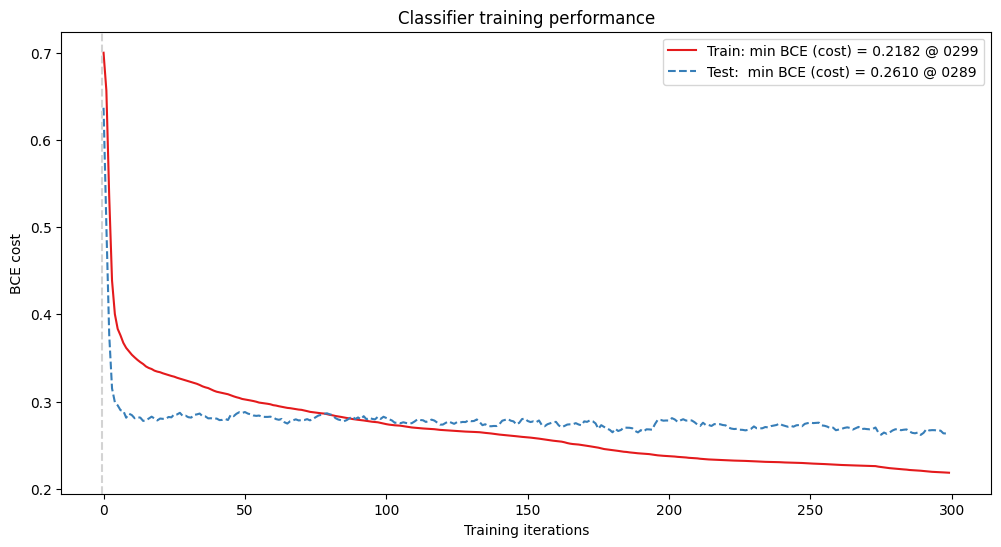

In [34]:
train_label = f'Train: min BCE (cost) = {round(train_min_obj, 5):05.4f} @ {train_min_obj_iter:04d}'
test_label =  f'Test:  min BCE (cost) = {round(test_min_obj, 5):05.4f} @ {test_min_obj_iter:04d}'
multi_plot_series(
    [train_obj_hist, test_bce_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'dashed'], # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='BCE cost', #ylim=(0, 1),
    legend_cols=1, smooth_weight=0.2, title='Classifier training performance')

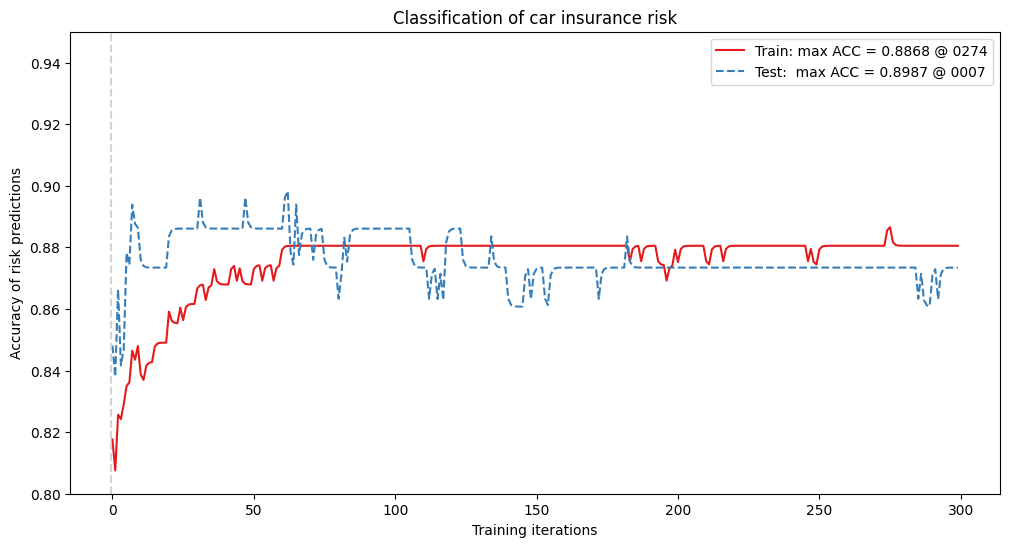

In [35]:
train_label = f'Train: max ACC = {round(train_max_acc, 5):05.4f} @ {train_max_acc_iter:04d}'
test_label =  f'Test:  max ACC = {round(test_max_acc, 5):05.4f} @ {test_max_acc_iter:04d}'
multi_plot_series(
    [train_acc_hist, test_acc_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'dashed'], ylim=(0.8, 0.95), # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='Accuracy of risk predictions',
    legend_cols=1, smooth_weight=0.2, title='Classification of car insurance risk')

### Confusion matrix and ROC chart

In [36]:
### Prepare data for plotting

# Get the opt test parameters
best_test_acc_params = hist_params[test_max_acc_iter]
q_auto.load_state_dict(best_test_acc_params)
best_test_pred = q_auto(X_test_tens)
best_test_acc = accuracy(y_test_tens, best_test_pred, prec=acc_prec)
print(f'Best test ACC: {best_test_acc:05.4f}')

# Prepare results for confusion matrix
print(f'Current format of targets: {y_test_tens[0:5]}')
true_best_test = torch.flatten(y_test_tens, start_dim=0, end_dim=-1).to(dtype=torch.int).detach().numpy()
print(f'Changed format of targets: {true_best_test[0:5]}')

print(f'Current format of predictions: {best_test_pred[0:5]}')
pred_best_test = torch.where(best_test_pred > 0.5, 1, 0)
pred_best_test = torch.flatten(pred_best_test, start_dim=0, end_dim=-1).to(dtype=torch.int).detach().numpy()
print(f'Changed format of predictions: {pred_best_test[0:5]}')

Best test ACC: 0.8987
Current format of targets: tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]], dtype=torch.float64)
Changed format of targets: [0 1 0 1 0]
Current format of predictions: tensor([[0.1458],
        [0.3050],
        [0.2270],
        [0.3334],
        [0.1854]], dtype=torch.float64, grad_fn=<SliceBackward0>)
Changed format of predictions: [0 0 0 0 0]


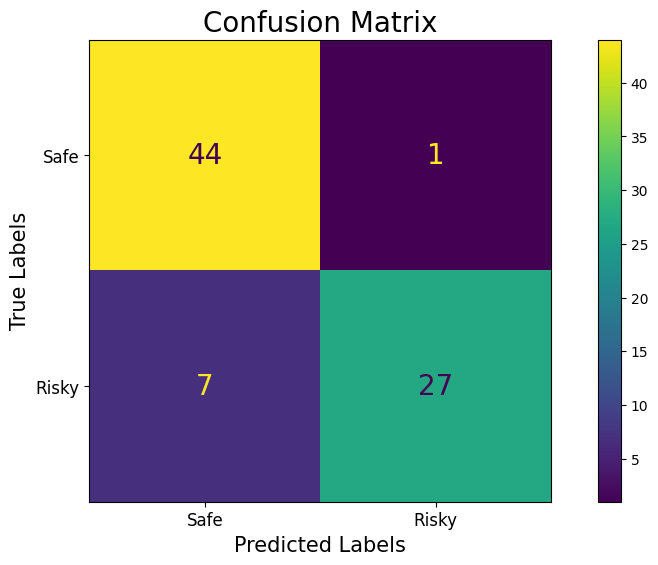

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Plot confusion matrix
cm = confusion_matrix(true_best_test, pred_best_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Risky'])
disp.plot()
for labels in disp.text_.ravel():
    labels.set_fontsize(20)  # Adjust the number as needed
disp.ax_.set_title("Confusion Matrix", fontsize=20)
disp.ax_.set_xlabel("Predicted Labels", fontsize=15)
disp.ax_.set_ylabel("True Labels", fontsize=15)
disp.ax_.tick_params(labelsize=12)
plt.show()

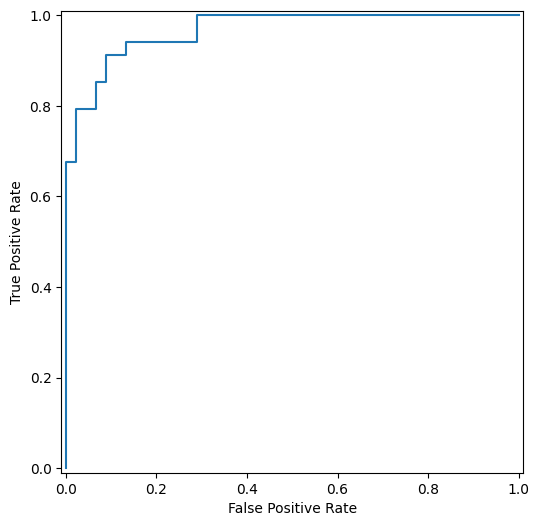

In [38]:
# Display ROC curve

from sklearn.metrics import RocCurveDisplay, roc_curve

# Plot the ROC curve
best_test_pred = best_test_pred.detach().numpy()
fpr, tpr, _ = roc_curve(true_best_test, best_test_pred, pos_label=1)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.show()

## <font color="blue">Model application</font>
*Note that the local copy of data has a different coding of certain columns, which had to be deleted as they were not numeric.*

In [39]:
import io

In [40]:
### Make a sample of 3 cars
X_car_data = """
,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,curb-weight,height,width,length,wheel-base,num-of-doors,normalized-losses
0,40000,16,12,6000,300,22,3.5,3.62,300,twelve,1000,40.0,66.9,189,90,four,122
1,15200,30,22,4000,90,7,3.0,3.33,80,two,1500,50.0,60.0,130,80,one,106
2,11850,28,21,5000,100,8,3.07,3.54,121,four,2658,56.1,60.0,150,100,two,100
"""
X_three_sel = pd.read_csv(io.StringIO(X_car_data), index_col=0)

In [41]:
### What was the original table (numeric values only)
X_std[0:3]

,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0.744589,0.0,0.475219,0.632836,0.616667,0.350,0.592708,0.4,0.415094,0.521429,0.609524,0.14375,0.470833,0.428571,0.166667,0.210526,0.352379
1,0.619048,0.0,0.230321,0.411940,0.308333,0.400,0.264158,0.2,0.139623,0.464286,0.457143,0.12500,0.091667,0.265306,0.444444,0.473684,0.177489
2,0.380952,1.0,0.189504,0.383582,0.325000,0.525,0.177269,0.2,0.113208,0.350000,0.514286,0.12500,0.083333,0.346939,0.500000,0.578947,0.147467


In [42]:
X_std.columns

Index(['normalized-losses', 'num-of-doors', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'num-of-cylinders', 'engine-size', 'bore',
       'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='str')

In [43]:
### What is the new data with the original columns (numeric values only)
#X_three_sel = X_three_sel.select_dtypes(include=np.number)
X_three_sel = X_three_sel[X_std.columns]
X_three_sel

,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,122,four,90,189,66.9,40.0,1000,twelve,300,3.62,3.50,22,300,6000,12,16,40000
1,106,one,80,130,60.0,50.0,1500,two,80,3.33,3.00,7,90,4000,22,30,15200
2,100,two,100,150,60.0,56.1,2658,four,121,3.54,3.07,8,100,5000,21,28,11850


In [44]:
X_three_sel.columns

Index(['normalized-losses', 'num-of-doors', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'num-of-cylinders', 'engine-size', 'bore',
       'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='str')

In [45]:
X_three_sel

,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,122,four,90,189,66.9,40.0,1000,twelve,300,3.62,3.50,22,300,6000,12,16,40000
1,106,one,80,130,60.0,50.0,1500,two,80,3.33,3.00,7,90,4000,22,30,15200
2,100,two,100,150,60.0,56.1,2658,four,121,3.54,3.07,8,100,5000,21,28,11850


In [46]:
### We need to standardise the data, apply PCA, change to angles and run the model

# Convert nominal to integer values
X_three_sel['num-of-doors'] = X_three_sel['num-of-doors'].map(num_doors_mapping)
X_three_sel['num-of-cylinders'] = X_three_sel['num-of-cylinders'].map(num_cylinders_mapping)

# Prepare test set
X_three_std = pd.DataFrame(auto_scaler.transform(X_three_sel), columns=X_three_sel.columns)
X_three_pca = auto_pca.transform(X_three_std)
X_three_pca = pd.DataFrame(X_three_pca, columns=[f'PC{n:02d}' for n in range(X_three_pca.shape[1])])
X_three_angles = angle_scaler.transform(X_three_pca)

# Get the opt test parameters and perform prediction
best_test_acc_params = hist_params[test_max_acc_iter]
q_auto.load_state_dict(best_test_acc_params)

# Create new records as input to the model and run
X_three_tens = torch.tensor(np.array(X_three_angles), dtype=torch.double)
q_auto(X_three_tens) > 0.5

tensor([[False],
        [ True],
        [ True]])

---

## Write your observations here

- Task 1 - run:
  - params = 75, epochs = 80, time = 47sec (00:00:47)<br>
    training: MSE = 0.1923 @ 0079, ACC = 0.7591 @ 0078<br>
    testing:  MSE = 0.2461 @ 0012, ACC = 0.5882 @ 0000<br>
    *Training seemed OK, but testing revealed, it wasn't!*
- Task 2 - class variable not random, so shuffle the data set:
  - _**This is also feature selection based on intuition:**_<br>
    params = 75, epochs = 80, time = 48sec (00:00:48)<br>
	training: MSE = 0.1979 @ 0079, ACC = 0.7153 @ 0067<br>
	testing:  MSE = 0.2371 @ 0047, ACC = 0.6029 @ 0017<br>
    *It does not look better, yet it had to be done!*
- Task 3 - feature selection (above was based on intuition):
  - _**Feature selection based on ANOVA F-Test**_<br>
    params = 75, epochs = 80, time = 47sec (00:00:47)<br>
	training: MSE = 0.1074 @ 0079, ACC = 0.8832 @ 0077<br>
	testing:  MSE = 0.1891 @ 0079, ACC = 0.7794 @ 0063<br>
    *Great improvement of model performance.*
  - _**Dimensionality reduction based on PCA**_<br>
	params = 75, epochs = 80, time = 47sec (00:00:47)<br>
	training: MSE = 0.1115 @ 0079, ACC = 0.8905 @ 0061<br>
	testing:  MSE = 0.1614 @ 0079, ACC = 0.7794 @ 0039<br>
    *Testing performance MSE/ACC was marginally better with PCA.*
  - _**Note 1**_: PCA ideally should have been applied to training<br>
    data and only then its transformation model then applied<br>
    to the testing partition.
  - _**Note 2**_: Shuffling could have been done at data partitioning,<br>
    however, non-random data would render PCA unreliable, so if<br>
    needed we could have done it twice.
- Task 4 - improve the model:
  - _**Encoding with larger margin**_ cell 25, x_angle_margin = 0.5<br>
	params = 75, epochs = 120, time = 48sec (00:00:47)<br>
	training: MSE = 0.1113 @ 0079, ACC = 0.8686 @ 0063<br>
	testing:  MSE = 0.1535 @ 0079, ACC = 0.8088 @ 0018<br>
    *Improvement to testing performance.*
  - _**Ineffective approaches**_<br>More layers (7), more or less features (4, 7),<br>
    *all resulted in test R2 < 0.8.*
  - _**Optionally added the Confusion Matrix and ROC chart**_
- Task 5:
  Added BCE loss which required changes to the quantum model and reliance on sigmoid.<br>
  Accuracy has not improved.
- Task 6:
  Lots of changes: adding nominal vars, LBFGS optimizer + closure, application.<br>
  Best performance overall:
  - training: BCE = 0.2182 @ 0299, ACC = 0.8868 @ 0274
  - testing:  BCE = 0.2610 @ 0289, ACC = 0.8987 @ 0007
- Challenge:
- Reflection:

## Modifications (do not remove)
Under the [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.txt) license, if you perform any changes to this notebook, please list them here, adding a note with your name, contact details, date and changes to the code.

- [Jacob Cybulski](http://jacobcybulski.com) (2025, 1 April): The author of this notebook added this section to record all code changes
- [Jacob Cybulski](http://jacobcybulski.com) (2026, 2 October): Now also compatible with...<br>
  pennylane                 0.45.0<br>
  pennylane_lightning       0.45.0<br>
  torch                     2.11.0+cpu<br>
  torchaudio                2.11.0<br>
  torchvision               0.26.0+cpu<br>

## Software (Linux)

In [47]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.45.0
pennylane_catalyst        0.15.0
pennylane_lightning       0.45.0
pennylane_lightning_gpu   0.45.0
torch                     2.11.0+cpu
torchaudio                2.11.0
torcheval                 0.0.7
torchmetrics              1.9.0
torchsummary              1.5.1
torchvision               0.26.0+cpu
